Loading Training Data:
Found 5169 files belonging to 2 classes.
Using 4136 files for training.

Loading Validation Data:
Found 5169 files belonging to 2 classes.
Using 1033 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


C:\Users\ddaak\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Starting high-speed training...
Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 49s 334ms/step - accuracy: 0.8259 - loss: 0.3791 - val_accuracy: 0.8829 - val_loss: 0.2769
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 307ms/step - accuracy: 0.8977 - loss: 0.2440 - val_accuracy: 0.8955 - val_loss: 0.2400
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 306ms/step - accuracy: 0.9113 - loss: 0.2147 - val_accuracy: 0.9003 - val_loss: 0.2341
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 304ms/step - accuracy: 0.9200 - loss: 0.1967 - val_accuracy: 0.9080 - val_loss: 0.2198
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 309ms/step - accuracy: 0.9197 - loss: 0.1940 - val_accuracy: 0.9109 - val_loss: 0.2147
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 309ms/step - accuracy: 0.9279 - loss: 0.1806 - val_accuracy: 0.9216 - val_loss: 0.2022
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 39s 300ms/step - accuracy: 0.9253 - loss: 0.1806 - val_accuracy: 0.9187 - val_loss: 0.2005
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 306ms/s

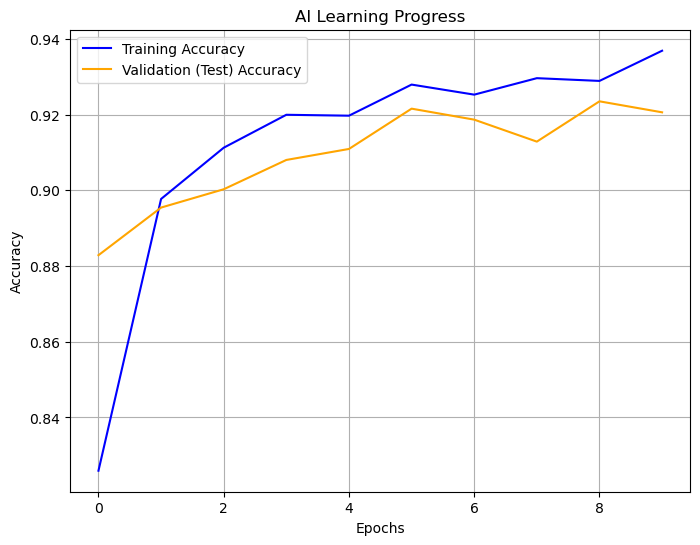


Success! Model saved safely to your local directory at: SmartWaste_Model.keras

Loading your Smart Waste AI for testing...
Model loaded successfully!



Please enter the local file path to an image of waste (e.g., 'C:/images/bottle.jpg' or 'test.jpg'):  'bootle.png'


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


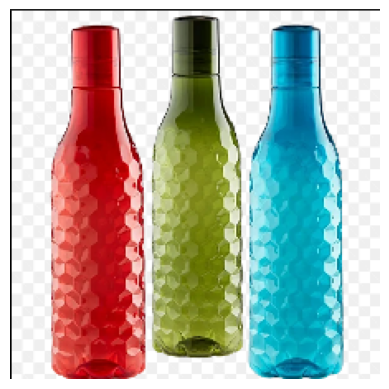


--- AI Prediction ---
Result: DRY WASTE (Recyclable)
Confidence: 91.89%


In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers  # Added missing imports
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

data_dir = './train' 
batch_size = 32
img_size = (224, 224)

print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

print("\nLoading Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)


base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

epochs = 10
print("Starting high-speed training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs
)

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy', color='orange')
plt.title('AI Learning Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

model_save_path = 'SmartWaste_Model.keras'
model.save(model_save_path)
print(f"\nSuccess! Model saved safely to your local directory at: {model_save_path}")




Loading your Smart Waste AI for testing...
Model loaded successfully!



Please enter the local file path to an image of waste (e.g., 'C:/images/bottle.jpg' or 'test.jpg'):  'bootle.png'


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


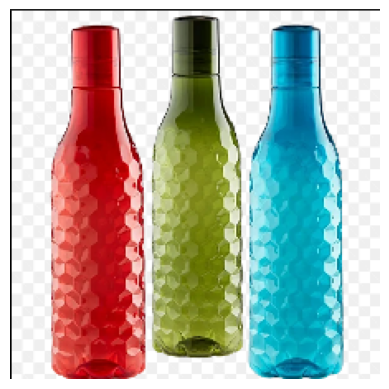


--- AI Prediction ---
Result: DRY WASTE (Recyclable)
Confidence: 91.89%


In [11]:
print("\nLoading your Smart Waste AI for testing...")
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model loaded successfully!\n")

img_path = input("Please enter the local file path to an image of waste (e.g., 'C:/images/bottle.jpg' or 'test.jpg'): ")

img_path = img_path.strip('\"\'')

if os.path.exists(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    predictions = loaded_model.predict(img_array)
    score = predictions[0][0]
    
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    print(f"\n--- AI Prediction ---")
    if score >= 0.5:
        print(f"Result: DRY WASTE (Recyclable)")
        print(f"Confidence: {(score * 100):.2f}%")
    else:
        print(f"Result: WET WASTE (Organic)")
        print(f"Confidence: {((1 - score) * 100):.2f}%")
else:
    print(f"Error: Could not find an image at '{img_path}'. Please check the path and try again.")